# 04 SQL Datenbank und analytische Abfragen 

## Ziel 

In diesem Notebook wird der aufbereitete Strompreisdatensatz in eine relationale SQL-Datenbank überführt und anschließend mit SQL analysiert 

Diese Datenbank dient als Verbindung zwischen der Datenaufbereitung in Python und der späteren Power BI Visualisierung

### 
- Aufbau einer relationalen Datenbank
- Speicherung der aufbereiteten Energiedaten
- Definition eines geeigneten Tabellenschemas
- Überführung von Pandas DataFrames in SQL
- Durchführung analytischer SQL-Abfragen
- Aggregation der Daten für spätere BI-Anwendungen
- Überprüfung der Datenqualität innerhalb der Datenbank


In [29]:
import pandas as pd
import matplotlib.pyplot as plt 
import sqlite3
from pathlib import Path
from IPython.display import display

In [3]:
#Datenbankordner erstellen
project_root = Path("..")

database_dir = project_root / "database"
database_dir.mkdir(exist_ok=True)

db_path = database_dir / "energy_analytics.db"

print("Datenbank:", db_path)

Datenbank: ..\database\energy_analytics.db


In [4]:
processed_path = (
    "../data/processed/"
    "energy_features_2023_2025.csv"
)
df = pd.read_csv(processed_path)

df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

print(df.shape)
df.head()

(26160, 21)


,timestamp,price,wind_offshore,wind_onshore,wind,solar,load,year,month,day,...,day_of_week,is_weekend,renewable_generation,residual_load,renewable_share_pct,price_lag_1,price_lag_24,price_lag_168,price_rolling_mean_24h,price_rolling_std_24h
0,2023-01-07 23:00:00+00:00,10.93,6974.950,24325.025,31299.975,0.000,42508.975,2023,1,7,...,5,True,31299.975,11209.00,73.631451,38.25,97.15,-5.17,85.216250,23.273035
1,2023-01-08 00:00:00+00:00,9.07,7076.325,23407.425,30483.750,0.000,40708.450,2023,1,8,...,6,True,30483.750,10224.70,74.883102,10.93,98.43,-1.07,81.492917,27.779032
2,2023-01-08 01:00:00+00:00,9.10,7021.775,22293.325,29315.100,0.000,39829.600,2023,1,8,...,6,True,29315.100,10514.50,73.601292,9.07,96.05,-1.47,77.870000,31.250968
3,2023-01-08 02:00:00+00:00,4.16,6752.250,21018.325,27770.575,0.000,40059.725,2023,1,8,...,6,True,27770.575,12289.15,69.322930,9.10,87.97,-5.08,74.377917,34.578714
4,2023-01-08 03:00:00+00:00,5.58,6865.125,20287.500,27152.625,1.325,40147.050,2023,1,8,...,6,True,27153.950,12993.10,67.636227,4.16,82.99,-4.49,71.152500,37.247771


In [55]:
df_energy = df 

In [5]:
#Überprüfe Daten 
print("Zeilen:", len(df))
print("Spalten:", len(df.columns))

print("\nSpalten:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isna().sum())

print("\nDuplikate:")
print(df["timestamp"].duplicated().sum())



Zeilen: 26160
Spalten: 21

Spalten:
['timestamp', 'price', 'wind_offshore', 'wind_onshore', 'wind', 'solar', 'load', 'year', 'month', 'day', 'hour', 'day_of_week', 'is_weekend', 'renewable_generation', 'residual_load', 'renewable_share_pct', 'price_lag_1', 'price_lag_24', 'price_lag_168', 'price_rolling_mean_24h', 'price_rolling_std_24h']

Missing Values:
timestamp                 0
price                     0
wind_offshore             0
wind_onshore              0
wind                      0
solar                     0
load                      0
year                      0
month                     0
day                       0
hour                      0
day_of_week               0
is_weekend                0
renewable_generation      0
residual_load             0
renewable_share_pct       0
price_lag_1               0
price_lag_24              0
price_lag_168             0
price_rolling_mean_24h    0
price_rolling_std_24h     0
dtype: int64

Duplikate:
0


## Überlegungen zum Datenbankschema

Bei der Überführung des aufbereiteten Energiedatensatzes in eine SQL-Datenbank sollte zunächst festgelegt werden, welche Informationen dauerhaft gespeichert und später für Analysen oder Visualisierungen benötigt werden. Dabei sollte das Schema einerseits möglichst vollständig sein, andererseits aber keine unnötigen oder redundanten Daten enthalten.

Als zentrale Beobachtungseinheit wird eine Stunde betrachtet. Jede Zeile der Tabelle energy_data beschreibt somit einen bestimmten Zeitpunkt und enthält die zu diesem Zeitpunkt beobachteten Strommarkt- und Erzeugungsdaten. Der timestamp bildet dabei den zeitlichen Bezugspunkt der Beobachtung.

Neben den ursprünglich erhobenen Größen wie Strompreis, Wind- und Solarerzeugung sowie elektrischer Last werden auch abgeleitete Merkmale gespeichert. Dazu gehören beispielsweise renewable_generation, residual_load und renewable_share_pct. Diese Variablen wurden bereits im Feature Engineering berechnet und ermöglichen weiterführende Analysen, ohne sie bei jeder späteren Abfrage erneut berechnen zu müssen.

Zusätzlich werden grundlegende Zeitmerkmale wie Jahr, Monat, Stunde und Wochentag gespeichert. Diese sind insbesondere für typische BI-Auswertungen relevant, beispielsweise zur Untersuchung von Preisunterschieden zwischen Jahren, Monaten, Tageszeiten oder Wochenenden und Werktagen.

Das resultierende Schema orientiert sich damit an der späteren Verwendung der Daten: SQL-Abfragen, statistische Analysen, Machine Learning und insbesondere die Visualisierung in Power BI. Da zunächst nur eine zentrale Beobachtungsebene betrachtet wird, ist eine einzelne Faktentabelle für das Projekt ausreichend. Eine komplexere Aufteilung in mehrere Fakt- und Dimensionstabellen wäre erst dann sinnvoll, wenn das Projekt um weitere Datenquellen oder unterschiedliche Entitäten erweitert wird.

In [6]:
#Verbindung zur SQLite Daatenbank herstellen
conn = sqlite3.connect(db_path)

print("Datenbankverbindung hergestellt.")

Datenbankverbindung hergestellt.


In [7]:
#DataFrame in SQL schreiben 
df.to_sql(
    "energy_data",
    conn,
    if_exists="replace",
    index=False
)

26160

In [9]:
#Überprüfe 
tables = pd.read_sql(
    """
    SELECT name
    FROM sqlite_master
    WHERE type='table';
    """,
    conn
)

tables

,name
0,energy_data


In [11]:
#Zeitraum mithilfe von SQL überprüfen 
query = """ 
SELECT 
    MIN(timestamp) AS start_date,
    MAX(timestamp) AS end_date 
FROM energy_data;
""" 

pd.read_sql(query,conn)

,start_date,end_date
0,2023-01-07 23:00:00+00:00,2026-01-01 22:00:00+00:00


In [12]:
#durchschnittlicher Strompreis 
query = """ 
SELECT 
    AVG(price) AS average_price, 
    MIN(price) AS min_price, 
    MAX(price) AS max_price 
FROM energy_data;
"""

pd.read_sql(query, conn)

,average_price,min_price,max_price
0,87.54978,-500.0,936.28


In [13]:
# Strompreise nach Jahr 
query = """ 
SELECT 
    year, 
    AVG(price) as average_price, 
    MIN(price) as min_price, 
    MAX(price) as max_price 
FROM energy_data
GROUP BY year
ORDER BY year; 
""" 

pd.read_sql(query, conn) 

,year,average_price,min_price,max_price
0,2023,95.189137,-500.00,524.270
1,2024,78.512268,-135.45,936.280
2,2025,89.328129,-250.32,583.400
3,2026,7.644457,-0.01,42.395


In [15]:
#negative Strompreise analysieren 
query = """ 
SELECT 
    year, 
    COUNT(*) AS negative_price_hours 
FROM energy_data 
WHERE price < 0 
GROUP BY year 
ORDER BY year; 
""" 

negative_prices = pd.read_sql(query, conn) 
negative_prices 

,year,negative_price_hours
0,2023,287
1,2024,457
2,2025,576
3,2026,4


In [18]:
# oder 
query = """ 
SELECT 
    year, 
    COUNT(*) AS negative_hours, 
    ROUND(
        100.0 * COUNT(*) / 
        (SELECT COUNT(*) 
        FROM energy_data e2
        WHERE e2.year = energy_data.year),
        2
    ) AS negative_price_share_pct 
FROM energy_data
WHERE price < 0 
GROUP BY year 
ORDER BY year; 
""" 

pd.read_sql(query, conn)

,year,negative_hours,negative_price_share_pct
0,2023,287,3.34
1,2024,457,5.20
2,2025,576,6.58
3,2026,4,17.39


In [20]:
# Wie unterscheiden sich die durchschnittlichen Strompreise nach Monat und Jahr 

query = """ 
SELECT 
    year, 
    month, 
    AVG(price) AS avg_price, 
    MIN(price) as min_price, 
    MAX(price) as max_price
FROM energy_data 
GROUP BY year, month
ORDER BY year , month
""" 

monthly_prices = pd.read_sql(query, conn)
monthly_prices.head(5)

,year,month,avg_price,min_price,max_price
0,2023,1,124.728146,0.01,270.22
1,2023,2,128.390923,22.01,245.60
2,2023,3,102.401142,-6.02,217.09
3,2023,4,100.832486,-8.82,207.92
4,2023,5,81.646371,-129.96,182.68


In [21]:
# Wind und Solarstromerzeugnis pro Jahr 

query = """ 
SELECT 
    year, 
    AVG(wind) AS avg_wind_generation, 
    AVG(solar) AS avg_solar_generation
FROM energy_data 
GROUP BY year 
ORDER BY year 
""" 

renewables_by_year = pd.read_sql(query, conn) 
renewables_by_year

,year,avg_wind_generation,avg_solar_generation
0,2023,15698.127042,6246.343562
1,2024,15519.548603,6797.234867
2,2025,14973.511675,8004.964135
3,2026,44996.280435,1751.693478


In [24]:
#Stundenprofil des Strommarktes
query = """ 
SELECT 
    hour, 
    AVG(price) as average_price
FROM energy_data
GROUP BY hour 
ORDER BY hour; 
""" 

hourly_prices = pd.read_sql(query, conn)
hourly_prices.head(5)

,hour,average_price
0,0,76.292961
1,1,74.361929
2,2,74.173555
3,3,78.056927
4,4,89.799672


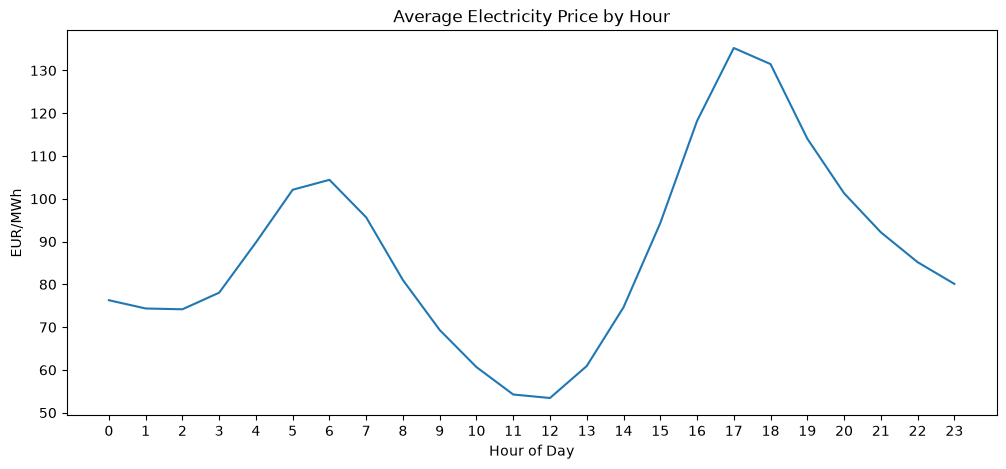

In [30]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_prices["hour"],
    hourly_prices["average_price"]
)

plt.xlabel("Hour of Day")
plt.ylabel("EUR/MWh")
plt.title("Average Electricity Price by Hour")

plt.xticks(range(24))

plt.show()

In [32]:
# Wie unterscheiden sich Strompreise -und Nachfrage zwischen Wochenende und Werktag
query = """ 
SELECT 
    is_weekend,
    AVG(price) AS average_price, 
    AVG(load) AS average_load
FROM energy_data 
GROUP BY is_weekend;
""" 

weekend_analysis = pd.read_sql(query,conn)
weekend_analysis

,is_weekend,average_price,average_load
0,0,95.236189,55466.835389
1,1,68.300292,46246.532770


In [33]:
#Extrempreise untersuchen 
#zeige die höchsten 20 Preise an 
query = """ 
SELECT 
    timestamp, 
    price, 
    wind, 
    solar, 
    load, 
    residual_load
FROM energy_data
ORDER BY price DESC 
LIMIT 20; 
""" 

highest_price = pd.read_sql(query, conn)
highest_price 

,timestamp,price,wind,solar,load,residual_load
0,2024-12-12 16:00:00+00:00,936.28,1336.825,28.675,68037.750,66672.250
1,2024-11-06 16:00:00+00:00,820.11,111.500,39.900,66422.825,66271.425
2,2024-12-12 15:00:00+00:00,818.98,1123.675,41.150,67272.150,66107.325
3,2024-11-06 17:00:00+00:00,805.08,102.525,33.925,65986.525,65850.075
4,2024-12-12 17:00:00+00:00,674.18,1460.350,18.225,67188.975,65710.400
5,2024-12-12 14:00:00+00:00,668.49,895.250,520.400,66739.300,65323.650
6,2024-09-03 17:00:00+00:00,656.37,2406.500,867.700,59422.350,56148.150
7,2024-12-12 07:00:00+00:00,655.60,872.650,168.950,67610.350,66568.750
8,2024-12-12 08:00:00+00:00,646.76,696.275,1114.000,67704.375,65894.100
9,2024-12-12 06:00:00+00:00,599.99,1029.250,7.475,64586.425,63549.700


In [34]:
query = """ 
SELECT 
    timestamp, 
    price, 
    wind, 
    solar, 
    load, 
    residual_load
FROM energy_data 
ORDER BY price ASC
LIMIT 20;
""" 

lowest_price = pd.read_sql(query,conn)
lowest_price

,timestamp,price,wind,solar,load,residual_load
0,2023-07-02 12:00:00+00:00,-500.00,16333.425,27278.275,43526.050,-85.650
1,2023-07-02 13:00:00+00:00,-399.00,18635.975,25657.125,42839.275,-1453.825
2,2023-07-02 11:00:00+00:00,-266.92,18102.850,26825.650,45618.500,690.000
3,2025-05-11 11:00:00+00:00,-250.32,1921.925,42123.750,40144.425,-3901.250
4,2025-05-11 12:00:00+00:00,-230.98,2106.700,40001.075,38923.575,-3184.200
5,2025-05-11 10:00:00+00:00,-212.82,2097.700,42931.750,42490.425,-2539.025
6,2023-07-02 10:00:00+00:00,-167.96,22142.400,25362.675,46959.675,-545.400
7,2024-05-12 11:00:00+00:00,-135.45,2768.050,38454.725,42343.225,1120.450
8,2024-05-12 12:00:00+00:00,-132.85,2814.000,36314.625,41101.050,1972.425
9,2025-05-01 11:00:00+00:00,-129.99,728.625,42402.000,41075.050,-2055.575


In [36]:
# Untersuche korrelation von preis und residual load 

query = """ 
SELECT 
    CASE 
        WHEN residual_load < 0 THEN "negative residual load" 
        WHEN residual_load < 1000 THEN "Low resiudal load"
        WHEN residual_load < 30000 THEN "medium residual load"
        ELSE "High residual load" 
    END AS residual_load_category, 

    AVG(price) AS average_price, 
    COUNT(*) AS observations 
FROM energy_data 

GROUP BY residual_load_category 
ORDER BY average_price; 
""" 

residual_load_analysis = pd.read_sql(query, conn)
residual_load_analysis 

,residual_load_category,average_price,observations
0,negative residual load,-26.876933,194
1,Low resiudal load,-21.036647,85
2,medium residual load,55.973672,12252
3,High residual load,118.241621,13629


In [37]:
# Datenqualität mit SQL überprüfen 

query = """ 
SELECT 
    COUNT(*) AS total_rows,
    COUNT(price) AS price_available,
    COUNT(wind) AS wind_available, 
    COUNT(solar) AS solar_available,
    COUNT(load) AS load_available 
FROM energy_data
""" 

pd.read_sql(query,conn)

,total_rows,price_available,wind_available,solar_available,load_available
0,26160,26160,26160,26160,26160


In [38]:
#Zeitstempel auf Duplikate überprüfen 
query = """
SELECT
    timestamp,
    COUNT(*) AS number_of_records
FROM energy_data
GROUP BY timestamp
HAVING COUNT(*) > 1;
"""

duplicates = pd.read_sql(query, conn)

duplicates

,timestamp,number_of_records


# SQL Abfragen in seperate Dateien auslagern

In [45]:
sql_path = project_root / "sql" / "price_analysis.sql"

with open(sql_path, "r", encoding="utf-8") as file:
    query = file.read()

price_by_year = pd.read_sql(query, conn)

price_by_year

,year,average_price,minimum_price,maximum_price
0,2023,95.189137,-500.00,524.270
1,2024,78.512268,-135.45,936.280
2,2025,89.328129,-250.32,583.400
3,2026,7.644457,-0.01,42.395


In [46]:
conn.close()

print("Datenbankverbindung geschlossen.")

Datenbankverbindung geschlossen.


# Datenbank für einfaches BI-Modell überprüfen 

In [49]:
conn = sqlite3.connect(db_path)

In [50]:
#Ausgangsbasis
tables = pd.read_sql(
    """
    SELECT name
    FROM sqlite_master
    WHERE type='table';
    """,
    conn
)

tables

,name
0,energy_data


In [51]:
# Struktur von energy_data überprüfen
# Was ist in der Datenbank vorhanden 
schema = pd.read_sql(
    "PRAGMA table_info(energy_data);",
    conn
)

schema

,cid,name,type,notnull,dflt_value,pk
0,0,timestamp,TIMESTAMP,0,None,0
1,1,price,REAL,0,None,0
2,2,wind_offshore,REAL,0,None,0
3,3,wind_onshore,REAL,0,None,0
4,4,wind,REAL,0,None,0
5,5,solar,REAL,0,None,0
6,6,load,REAL,0,None,0
7,7,year,INTEGER,0,None,0
8,8,month,INTEGER,0,None,0
9,9,day,INTEGER,0,None,0


In [52]:
#Datumstabelle erzeugen 
# Datensatz ist stündlich
# wir brauchen einen Datensatz pro Tag 

date_range = pd.date_range(
    start="2023-01-01",
    end="2025-12-31",
    freq="D"
)

dim_date = pd.DataFrame({
    "date": date_range
})

dim_date.head()

,date
0,2023-01-01
1,2023-01-02
2,2023-01-03
3,2023-01-04
4,2023-01-05


In [53]:
# erzeuge BI relevante Attribute 
dim_date["year"] = dim_date["date"].dt.year

dim_date["quarter"] = dim_date["date"].dt.quarter

dim_date["month"] = dim_date["date"].dt.month

dim_date["month_name"] = dim_date["date"].dt.month_name()

dim_date["week"] = dim_date["date"].dt.isocalendar().week

dim_date["day"] = dim_date["date"].dt.day

dim_date["day_of_week"] = dim_date["date"].dt.dayofweek

dim_date["day_name"] = dim_date["date"].dt.day_name()

dim_date["is_weekend"] = (
    dim_date["day_of_week"] >= 5
)

In [56]:
#erzeuge gemeinsamen Schlüssel 
# ergänze Datum in fact_energy 
df_energy["date"] = (
    df_energy["timestamp"]
    .dt.tz_localize(None)
    .dt.normalize()
)

In [57]:
df_energy[
    ["timestamp", "date"]
].head()

,timestamp,date
0,2023-01-07 23:00:00+00:00,2023-01-07
1,2023-01-08 00:00:00+00:00,2023-01-08
2,2023-01-08 01:00:00+00:00,2023-01-08
3,2023-01-08 02:00:00+00:00,2023-01-08
4,2023-01-08 03:00:00+00:00,2023-01-08


In [58]:
dim_date.to_sql(
    "dim_date",
    conn,
    if_exists="replace",
    index=False
)

1096

Ein Datum in dim_date gehört nun zu vielen stündlichen Beobachtungen in energy_data.

In [61]:
# nachdem date ergänzt wurde Faktentabelle aktualisiseren 

df_energy.to_sql(
    "energy_data",
    conn,
    if_exists="replace",
    index=False
)

26160

In [62]:
pd.read_sql(
    "SELECT * FROM energy_data LIMIT 5;",
    conn
)

,timestamp,price,wind_offshore,wind_onshore,wind,solar,load,year,month,day,...,is_weekend,renewable_generation,residual_load,renewable_share_pct,price_lag_1,price_lag_24,price_lag_168,price_rolling_mean_24h,price_rolling_std_24h,date
0,2023-01-07 23:00:00+00:00,10.93,6974.950,24325.025,31299.975,0.000,42508.975,2023,1,7,...,1,31299.975,11209.00,73.631451,38.25,97.15,-5.17,85.216250,23.273035,2023-01-07 00:00:00
1,2023-01-08 00:00:00+00:00,9.07,7076.325,23407.425,30483.750,0.000,40708.450,2023,1,8,...,1,30483.750,10224.70,74.883102,10.93,98.43,-1.07,81.492917,27.779032,2023-01-08 00:00:00
2,2023-01-08 01:00:00+00:00,9.10,7021.775,22293.325,29315.100,0.000,39829.600,2023,1,8,...,1,29315.100,10514.50,73.601292,9.07,96.05,-1.47,77.870000,31.250968,2023-01-08 00:00:00
3,2023-01-08 02:00:00+00:00,4.16,6752.250,21018.325,27770.575,0.000,40059.725,2023,1,8,...,1,27770.575,12289.15,69.322930,9.10,87.97,-5.08,74.377917,34.578714,2023-01-08 00:00:00
4,2023-01-08 03:00:00+00:00,5.58,6865.125,20287.500,27152.625,1.325,40147.050,2023,1,8,...,1,27153.950,12993.10,67.636227,4.16,82.99,-4.49,71.152500,37.247771,2023-01-08 00:00:00


In [63]:
pd.read_sql(
    "SELECT * FROM dim_date LIMIT 5;",
    conn
)

,date,year,quarter,month,month_name,week,day,day_of_week,day_name,is_weekend
0,2023-01-01 00:00:00,2023,1,1,January,52,1,6,Sunday,1
1,2023-01-02 00:00:00,2023,1,1,January,1,2,0,Monday,0
2,2023-01-03 00:00:00,2023,1,1,January,1,3,1,Tuesday,0
3,2023-01-04 00:00:00,2023,1,1,January,1,4,2,Wednesday,0
4,2023-01-05 00:00:00,2023,1,1,January,1,5,3,Thursday,0


In [65]:
pd.read_sql(
    "SELECT * FROM dim_date LIMIT 5;",
    conn
)

,date,year,quarter,month,month_name,week,day,day_of_week,day_name,is_weekend
0,2023-01-01 00:00:00,2023,1,1,January,52,1,6,Sunday,1
1,2023-01-02 00:00:00,2023,1,1,January,1,2,0,Monday,0
2,2023-01-03 00:00:00,2023,1,1,January,1,3,1,Tuesday,0
3,2023-01-04 00:00:00,2023,1,1,January,1,4,2,Wednesday,0
4,2023-01-05 00:00:00,2023,1,1,January,1,5,3,Thursday,0


In [66]:
pd.read_sql(
    """
    SELECT name
    FROM sqlite_master
    WHERE type='table';
    """,
    conn
)

,name
0,dim_date
1,energy_data


In [67]:
pd.read_sql(
    "PRAGMA table_info(energy_data);",
    conn
)

,cid,name,type,notnull,dflt_value,pk
0,0,timestamp,TIMESTAMP,0,None,0
1,1,price,REAL,0,None,0
2,2,wind_offshore,REAL,0,None,0
3,3,wind_onshore,REAL,0,None,0
4,4,wind,REAL,0,None,0
5,5,solar,REAL,0,None,0
6,6,load,REAL,0,None,0
7,7,year,INTEGER,0,None,0
8,8,month,INTEGER,0,None,0
9,9,day,INTEGER,0,None,0


prüfe ob date key funktioniert 

In [69]:
pd.read_sql(
    """
    SELECT 
        COUNT(*) AS rows,
        COUNT(DISTINCT date) AS distinct_dates
    FROM energy_data;
    """,
    conn
)

,rows,distinct_dates
0,26160,1091


In [70]:
pd.read_sql(
    """
    SELECT 
        COUNT(*) AS rows,
        COUNT(DISTINCT date) AS distinct_dates
    FROM dim_date;
    """,
    conn
)

,rows,distinct_dates
0,1096,1096


In [71]:
# join testen 
test_join = pd.read_sql(
    """
    SELECT
        e.timestamp,
        e.date,
        d.year,
        d.month,
        d.month_name,
        d.day_name,
        d.is_weekend
    FROM energy_data e
    LEFT JOIN dim_date d
        ON e.date = d.date
    LIMIT 20;
    """,
    conn
)

test_join

,timestamp,date,year,month,month_name,day_name,is_weekend
0,2023-01-07 23:00:00+00:00,2023-01-07 00:00:00,2023,1,January,Saturday,1
1,2023-01-08 00:00:00+00:00,2023-01-08 00:00:00,2023,1,January,Sunday,1
2,2023-01-08 01:00:00+00:00,2023-01-08 00:00:00,2023,1,January,Sunday,1
3,2023-01-08 02:00:00+00:00,2023-01-08 00:00:00,2023,1,January,Sunday,1
4,2023-01-08 03:00:00+00:00,2023-01-08 00:00:00,2023,1,January,Sunday,1
5,2023-01-08 04:00:00+00:00,2023-01-08 00:00:00,2023,1,January,Sunday,1
6,2023-01-08 05:00:00+00:00,2023-01-08 00:00:00,2023,1,January,Sunday,1
7,2023-01-08 06:00:00+00:00,2023-01-08 00:00:00,2023,1,January,Sunday,1
8,2023-01-08 07:00:00+00:00,2023-01-08 00:00:00,2023,1,January,Sunday,1
9,2023-01-08 08:00:00+00:00,2023-01-08 00:00:00,2023,1,January,Sunday,1


In [72]:
# prüfe auf fehlende zuordnungen 
pd.read_sql(
    """
    SELECT COUNT(*) AS missing_dates
    FROM energy_data e
    LEFT JOIN dim_date d
        ON e.date = d.date
    WHERE d.date IS NULL;
    """,
    conn
)

,missing_dates
0,23


dim_date enthält nur datumswerte bis zum 31.12.2025

die Tabelle energy_data enthält allerdings 23 zusätzliche werte für den 1.1.2026 

Dies soll nun korrigiert werden 

In [73]:
date_range = pd.date_range(
    start="2023-01-01",
    end="2026-12-31",
    freq="D"
)

In [74]:
# Attribute erneut erzeugen 
dim_date = pd.DataFrame({
    "date": date_range
})

dim_date["year"] = dim_date["date"].dt.year
dim_date["quarter"] = dim_date["date"].dt.quarter
dim_date["month"] = dim_date["date"].dt.month
dim_date["month_name"] = dim_date["date"].dt.month_name()

dim_date["week"] = dim_date["date"].dt.isocalendar().week
dim_date["day"] = dim_date["date"].dt.day
dim_date["day_of_week"] = dim_date["date"].dt.dayofweek
dim_date["day_name"] = dim_date["date"].dt.day_name()

dim_date["is_weekend"] = (
    dim_date["day_of_week"] >= 5
)

In [75]:
# ergänze Spalten 
dim_date["year_month"] = (
    dim_date["year"].astype(str)
    + "-"
    + dim_date["month"].astype(str).str.zfill(2)
)

dim_date["year_month_key"] = (
    dim_date["year"] * 100
    + dim_date["month"]
)

In [76]:
# speicher wieder in SQL lite 
dim_date.to_sql(
    "dim_date",
    conn,
    if_exists="replace",
    index=False
)

1461

In [77]:
# überprüfen 
pd.read_sql(
    """
    SELECT COUNT(*) AS missing_dates
    FROM energy_data e
    LEFT JOIN dim_date d
        ON e.date = d.date
    WHERE d.date IS NULL;
    """,
    conn
)

,missing_dates
0,0


In [78]:
# erweitere dim_date bis 2027 
# größer als der bisherige Datenbestand aber dadurch "zukunftsicher"
date_range = pd.date_range(
    start="2023-01-01",
    end="2027-12-31",
    freq="D"
)

In [79]:
conn.close()

In [80]:
conn = sqlite3.connect(db_path)
print(db_path)

..\database\energy_analytics.db


In [81]:
pd.read_sql(
    """
    SELECT COUNT(*) AS missing_dates
    FROM energy_data e
    LEFT JOIN dim_date d
        ON e.Date = d.date
    WHERE d.date IS NULL;
    """,
    conn
)

,missing_dates
0,0
